1. LeNet-5

In [1]:
!pip install --user tqdm

In [3]:
import torch
import torchvision
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms #이미지 변환 ( 전처리 ) 기능을 제공하는 라이브러리
from torch.autograd import Variable
from torch import optim #경사 하강법을 이용하여 가중치를 구하기 위한 옵티마이저 라이브러리
import torch.nn as nn
import torch.nn.functional as F
import os #파일 경로에 대한 함수들을 제공
import cv2
from PIL import Image
from tqdm import tqdm_notebook as tqdm #진행 상황을 가시적으로 표현해 주는데 , 특히 모델의 학습 경과를 확인하고 싶을 때 사용
import random 
from matplotlib import pyplot as plt
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [9]:
# 이미지 데이터셋 전처리(텐서 변환)
class ImageTransforms:
    def __init__(self, resize, mean, std):
        self.data_transform = {
            'train': transforms.Compose([
                transforms.RandomResizedCrop(resize, scale=(0.5,1.0)),
                transforms.RandomHorizontalFlip(),
                transforms.ToTensor(),
                transforms.Normalize(mean, std)
            ]),
            'val': transforms.Compose([
                transforms.Resize (256),
                transforms.CenterCrop(resize),
                transforms.ToTensor(),
                transforms.Normalize(mean, std)
            ])
        }
    def __call__(self,img,phase):
        return self.data_transform[phase](img)
        
        
        
        

In [11]:
#이미지 데이터셋을 불러온 후 훈련, 검증, 테스트로 분리
cat_directory=r'/Users/bluecloud/Documents/대학/유런/data/chap06/dogs-vs-cats/Cat'
dog_directory=r'/Users/bluecloud/Documents/대학/유런/data/chap06/dogs-vs-cats/Dog/'

cat_images_filepaths=sorted([os.path.join(cat_directory, f) for f in
                             os.listdir(cat_directory)])
dog_images_filepaths=sorted([os.path.join(dog_directory, f) for f in
                             os.listdir(dog_directory)])
images_filepaths=[*cat_images_filepaths, *dog_images_filepaths] #개고양이 이미지 합쳐서 여기에 저장
correct_images_filepaths=[i for i in images_filepaths if cv2.imread(i) is not None]

random.seed(42)
random.shuffle(correct_images_filepaths)
train_images_filepaths=correct_images_filepaths[:400] # 훈련용
val_images_filepaths=correct_images_filepaths[400:-10] # 검증용
test_images_filepaths=correct_images_filepaths[-10:] # 테스트용
print(len(train_images_filepaths), len(val_images_filepaths), len(test_images_filepaths))

400 92 10


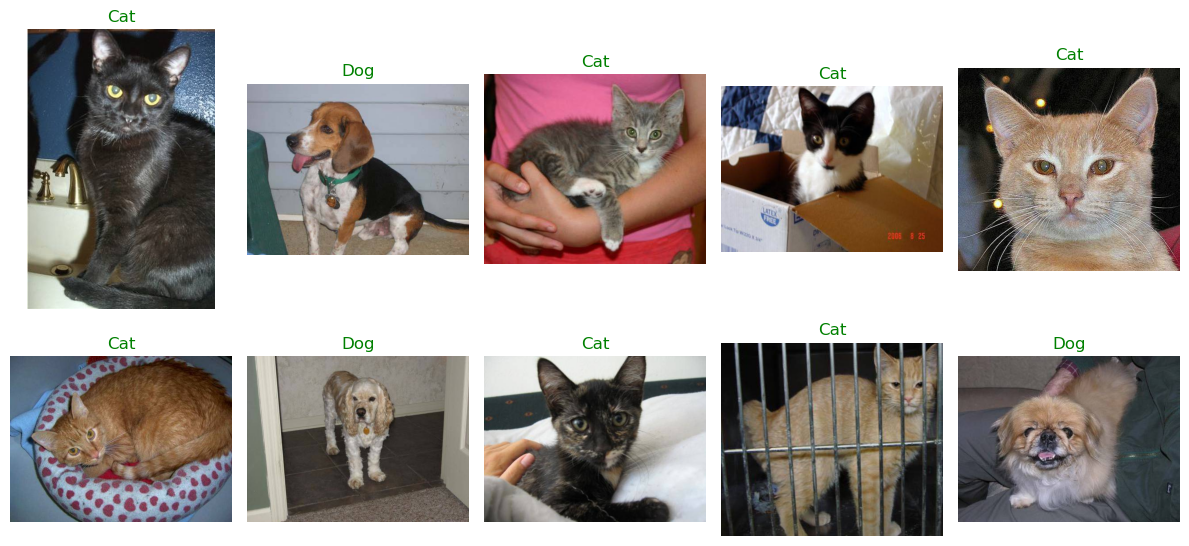

In [13]:
#테스트 데이터셋 이미지 확인 함수 
def display_image_grid(images_filepaths, predicted_labels=(), cols=5):
    rows=len(images_filepaths) // cols
    figure, ax=plt.subplots(nrows=rows, ncols=cols, figsize=(12, 6))
    for i, image_filepath in enumerate(images_filepaths):
        image=cv2.imread(image_filepath)
        image=cv2.cvtColor(image, cv2.COLOR_BGR2RGB)    
        true_label=os.path.normpath(image_filepath).split(os.sep)[-2] 
        predicted_label=predicted_labels[i] if predicted_labels else true_label
        color="green" if true_label==predicted_label else "red" # 예측과 정답이 동일하면 초록, 아니면 빨강
        ax.ravel()[i].imshow(image)
        ax.ravel()[i].set_title(predicted_label, color=color)
        ax.ravel()[i].set_axis_off() # 이미지 축 제거
    plt.tight_layout() # 여백 조정
    plt.show()

# 테스트 데이터셋 이미지 출력
display_image_grid(test_images_filepaths)

In [15]:
#이미지 데이터셋 클래스 정의
class DogvsCatDataset(Dataset):
    def __init__(self, file_list, transform=None, phase='train'): # 경로만 지정
        self.file_list=file_list
        self.transform=transform
        self.phase=phase

    def __len__(self):
        return len(self.file_list)

    def __getitem__(self, idx): #데이터셋에서 데이터를 가져오는 부분으로 결과는 텐서 형태가 됨
        img_path=self.file_list[idx]
        img=Image.open(img_path) # 여기서 이미지 데이터 가져옴
        img_transformed=self.transform(img, self.phase) # 이미지에 train 전처리 적용
        label=img_path.split('/')[-1].split('.')[0] #이미지 데이터에 대한 레이블 값(dog, cat)을 가져옴
        if label=='dog':
            label=1
        elif label=='cat':
            label=0
        return img_transformed, label

In [17]:
#변수 값 정의
size=224
mean=(0.485, 0.456, 0.406)
std=(0.229, 0.224, 0.225)
batch_size=32 # 한 번에 불러오는게 아니라 배치 사이즈만큼 분할해서 가져옴

In [23]:
#이미지 데이터셋 정의
train_dataset=DogvsCatDataset(train_images_filepaths, transform=ImageTransforms(size,
                                mean, std), phase='train')
val_dataset=DogvsCatDataset(val_images_filepaths, transform=ImageTransforms(size,
                                mean, std), phase='val')
index=0
print(train_dataset.__getitem__(index)[0].size()) # 훈련 데이터의 크기 출력
print(train_dataset.__getitem__(index)[1]) #훈련 데이터의 레이블

torch.Size([3, 224, 224])
0


In [27]:
#데이터로더 정의
train_dataloader=DataLoader(train_dataset, batch_size=batch_size, shuffle=True) 
val_dataloader=DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
dataloader_dict={'train': train_dataloader, 'val': val_dataloader} #훈련+검증해서 표현

batch_iterator=iter(train_dataloader)
inputs, label=next(batch_iterator)
print(inputs.size())
print(label)
     

torch.Size([32, 3, 224, 224])
tensor([0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1,
        1, 1, 1, 1, 0, 1, 1, 1])


In [29]:
# 데이터셋을 학습시킬 모델의 네트워크 설계하는 클래스 생성
#모델의 네트워크 클래스
class LeNet(nn.Module):
    def __init__(self):
        super(LeNet, self).__init__()
        self.cnn1=nn.Conv2d(in_channels=3, out_channels=16, kernel_size=5, stride=1,
                            padding=0) #2d 합성곱층의 적용 : 입력은 아까 그거 torch.Size([3, 224, 224]) >> 출력은 (16,220,220)
        self.relu1=nn.ReLU()
        self.maxpool1=nn.MaxPool2d(kernel_size=2) # 최대 풀링 적용 >> 220/2되서 (16,110,110)
        self.cnn2=nn.Conv2d(in_channels=16, out_channels=32, kernel_size=5,
                            stride=1, padding=0) #2d 합성곱층의 적용 : 입력은 (16,110,110) >> 출력은 (32,106,106)
        self.relu2=nn.ReLU()
        self.maxpool2=nn.MaxPool2d(kernel_size=2) # 최대 풀링 적용 >> 106/2되서 (32,53,53)

        self.fc1=nn.Linear(32*53*53, 512)
        self.relu5=nn.ReLU()
        self.fc2=nn.Linear(512, 2)
        self.output=nn.Softmax(dim=1)

    def forward(self, x):
        out=self.cnn1(x)
        out=self.relu1(out)
        out=self.maxpool1(out)
        out=self.cnn2(out)
        out=self.relu2(out)
        out=self.maxpool2(out)
        out=out.view(out.size(0), -1) #완전 연결층에 데이터 전달하려면 1차원으로 형태 바꿔야함
        out=self.fc1(out)
        out=self.fc2(out)
        out=self.output(out)
        return out
     

In [31]:
# 모델 생성
model=LeNet()
print(model)

LeNet(
  (cnn1): Conv2d(3, 16, kernel_size=(5, 5), stride=(1, 1))
  (relu1): ReLU()
  (maxpool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (cnn2): Conv2d(16, 32, kernel_size=(5, 5), stride=(1, 1))
  (relu2): ReLU()
  (maxpool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=89888, out_features=512, bias=True)
  (relu5): ReLU()
  (fc2): Linear(in_features=512, out_features=2, bias=True)
  (output): Softmax(dim=1)
)


In [33]:
# 출력 결과를 한눈에 들어오도록
!pip install torchsummary

In [37]:
#torchsummary로 모델 네트워크 구조 확인
from torchsummary import summary
summary(model, input_size=(3,224,224))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 16, 220, 220]           1,216
              ReLU-2         [-1, 16, 220, 220]               0
         MaxPool2d-3         [-1, 16, 110, 110]               0
            Conv2d-4         [-1, 32, 106, 106]          12,832
              ReLU-5         [-1, 32, 106, 106]               0
         MaxPool2d-6           [-1, 32, 53, 53]               0
            Linear-7                  [-1, 512]      46,023,168
            Linear-8                    [-1, 2]           1,026
           Softmax-9                    [-1, 2]               0
Total params: 46,038,242
Trainable params: 46,038,242
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.57
Forward/backward pass size (MB): 19.47
Params size (MB): 175.62
Estimated Total Size (MB): 195.67
--------------------------------

In [39]:
# 학습 가능한 파라미터 수 확인  >> model.parameters()로 확인 >> 그냥 정보 확인을 위한 코드임
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f'The model has {count_parameters(model):,} trainable parameters')

The model has 46,038,242 trainable parameters


>> 완전 많음 일부 이미지만 사용될듯?

In [41]:
#옵티마이저와 손실 함수 정의
optimizer=optim.SGD(model.parameters(), lr=0.001, momentum=0.9)
criterion=nn.CrossEntropyLoss()
#모델의 파라미터와 손실 함수를 CPU에 할당
model=model.to(device)
criterion=criterion.to(device)

In [45]:
# 모델 학습 함수 정의 >> 학습 용도이므로 model.train() 사용
def train_model(model, dataloader_dict, criterion, optimizer, num_epoch):
    since=time.time()
    best_acc=0.0

    for epoch in range(num_epoch):
        print('Epoch {}/{}'.format(epoch+1, num_epoch))
        print('-'*20)

        for phase in ['train', 'val']:
            if phase=='train':
                model.train()
            else:
                model.eval()

            epoch_loss=0.0
            epoch_corrects=0

            for inputs, labels in tqdm(dataloader_dict[phase]): #dataloader_dict : 이거 훈련 데이터셋이 될듯
                inputs=inputs.to(device)
                labels=labels.to(device)
                optimizer.zero_grad()

                with torch.set_grad_enabled(phase=='train'):
                    outputs=model(inputs)
                    _, preds=torch.max(outputs, 1)
                    loss=criterion(outputs, labels)

                    if phase=='train':
                        loss.backward() # 모든 파라미터에 대해 기울기 계산
                        optimizer.step() # 파라미터 갱신

                    epoch_loss+=loss.item()*inputs.size(0)
                    epoch_corrects+=torch.sum(preds==labels.data)

            epoch_loss=epoch_loss/len(dataloader_dict[phase].dataset)
            epoch_acc=epoch_corrects.double()/len(dataloader_dict[phase].dataset)
            print('{} Loss: {:.4f} Acc: {:.4f}'.format(phase, epoch_loss, epoch_acc))

            if phase=='val' and epoch_acc>best_acc: # 검증 데이터셋에 대해 가장 최적의 정확도 저장
                best_acc=epoch_acc
                best_model_wts=model.state_dict()

    time_elapsed=time.time() -since
    print('Training complete in {:.0f}m {:.0f}s'.format(time_elapsed//60, time_elapsed%60))
    print('Best val Acc: {:4f}'.format(best_acc))
    return model
     

In [47]:
# 모델 학습 >> train_model 출격
import time

num_epoch=10
model=train_model(model, dataloader_dict, criterion, optimizer, num_epoch)

Epoch 1/10
--------------------


/var/folders/2c/j3wmswps2r5gclvj1skrczqh0000gn/T/ipykernel_51588/2920202219.py:19: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for inputs, labels in tqdm(dataloader_dict[phase]): #dataloader_dict : 이거 훈련 데이터셋이 될듯


  0%|          | 0/13 [00:00<?, ?it/s]

train Loss: 0.6934 Acc: 0.5125


  0%|          | 0/3 [00:00<?, ?it/s]

...

val Loss: 0.6784 Acc: 0.5870
Epoch 10/10
--------------------


  0%|          | 0/13 [00:00<?, ?it/s]

train Loss: 0.6489 Acc: 0.6350


  0%|          | 0/3 [00:00<?, ?it/s]

val Loss: 0.6949 Acc: 0.5435
Training complete in 6m 43s
Best val Acc: 0.597826


In [55]:
#모델 테스트를 위한 함수 정의  >> 정확도 측정해서 csv 파일로 저장
import pandas as pd

id_list=[]
pred_list=[]
_id=0
with torch.no_grad(): # 역전파 중 텐서에 대한 변화도 계산할 필요가 없음을 의미 >> 훈련 데이터셋 학습과 가장 큰 차이점
    for test_path in tqdm(test_images_filepaths):
        img=Image.open(test_path)
        _id=test_path.split('/')[-1].split('.')[1]
        transform=ImageTransforms(size, mean, std)
        img=transform(img, phase='val')
        img=img.unsqueeze(0)    #텐서에 차원을 추가
        img=img.to(device)

        model.eval()
        outputs=model(img)
        preds=F.softmax(outputs, dim=1)[:, 1].tolist()    #지정된 차원을 따라 텐서의 요소가 (0,1) 범위에 있고, 합계가 1이 되도록 조정
        id_list.append(_id)
        pred_list.append(preds[0])
res=pd.DataFrame({
    'id': id_list,
    'label': pred_list
})

res.sort_values(by='id', inplace=True)
res.reset_index(drop=True, inplace=True)

res.to_csv('/Users/bluecloud/Documents/대학/유런/data/chap06/predictions.csv', index=False)

/var/folders/2c/j3wmswps2r5gclvj1skrczqh0000gn/T/ipykernel_51588/1989824106.py:8: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for test_path in tqdm(test_images_filepaths):


  0%|          | 0/10 [00:00<?, ?it/s]

In [57]:
#테스트 데이터셋의 예측결과 호출
res.head(10)

,id,label
0,109,0.564653
1,145,0.451740
2,15,0.609144
3,162,0.531125
4,167,0.561944
5,200,0.507271
6,210,0.661168
7,211,0.680880
8,213,0.465212
9,224,0.656852


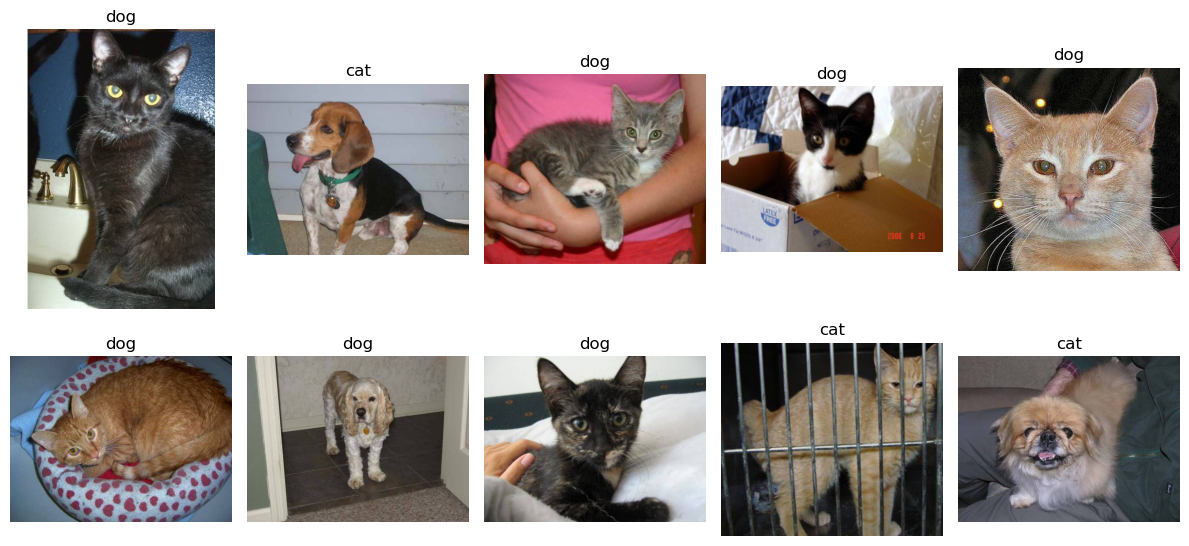

In [59]:
# 테스트 데이터셋 이미지를 출력하기 위한 함수 >> 0.5보다 크면 개, 0.5보다 작으면 고앵
class_=classes={0: 'cat', 1:'dog'} # 개묘에 대한 클래스 정의
def display_image_grid(images_filepaths, predicted_labels=(), cols=5):
    rows=len(images_filepaths)//cols
    figure, ax=plt.subplots(nrows=rows, ncols=cols, figsize=(12,6))
    for i, image_filepath in enumerate(images_filepaths):
        image=cv2.imread(image_filepath)
        image=cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        a=random.choice(res['id'].values)
        label=res.loc[res['id']==a, 'label'].values[0]
        if label>0.5:
            label=1
        else:
            label=0
        ax.ravel()[i].imshow(image)
        ax.ravel()[i].set_title(class_[label])
        ax.ravel()[i].set_axis_off()
    plt.tight_layout()
    plt.show()
# 예측 결과 이미지 출력(테스트 데이터셋을 파라미터로 전달
display_image_grid(test_images_filepaths)

2. AlexNet

In [61]:
#필요한 라이브러리 호출
import torch
import torchvision
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from torch.autograd import Variable
from torch import optim
import torch.nn as nn
import torch.nn.functional as F
import os
import cv2
import random
from PIL import Image
from tqdm import tqdm_notebook as tqdm
device=torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [63]:

#데이터 전처리
class ImageTransforms():
    def __init__(self, resize, mean, std):
        self.data_transform={
            'train': transforms.Compose([
                transforms.RandomResizedCrop(resize, scale=(0.5, 1.0)),
                transforms.RandomHorizontalFlip(),
                transforms.ToTensor(),
                transforms.Normalize(mean, std)
            ]),
            'val': transforms.Compose([
                transforms.Resize(256),
                transforms.CenterCrop(resize),
                transforms.ToTensor(),
                transforms.Normalize(mean, std)
            ])
        }

    def __call__(self, img, phase):
        return self.data_transform[phase](img)

In [65]:
#데이터를 가져와서 훈련, 검증, 테스트 용도로 분리
cat_directory=r'/Users/bluecloud/Documents/대학/유런/data/chap06/dogs-vs-cats/Cat'
dog_directory=r'/Users/bluecloud/Documents/대학/유런/data/chap06/dogs-vs-cats/Dog/'

cat_images_filepaths=sorted([os.path.join(cat_directory, f) for f in
                             os.listdir(cat_directory)])
dog_images_filepaths=sorted([os.path.join(dog_directory, f) for f in
                             os.listdir(dog_directory)])
images_filepaths=[*cat_images_filepaths, *dog_images_filepaths]
correct_images_filepaths=[i for i in images_filepaths if cv2.imread(i) is not None]

random.seed(42)
random.shuffle(correct_images_filepaths)
train_images_filepaths=correct_images_filepaths[:400]
val_images_filepaths=correct_images_filepaths[400:-10]
test_images_filepaths=correct_images_filepaths[-10:]
print(len(train_images_filepaths), len(val_images_filepaths), len(test_images_filepaths))

400 92 10


In [67]:
#커스텀 데이터셋 정의
class DogvsCatDataset(Dataset):
    def __init__(self, file_list, transform=None, phase='train'):
        self.file_list=file_list
        self.transform=transform
        self.phase=phase #self.phase >> ImageTransforms()에서 정의한 train과 val

    def __len__(self):
        return len(self.file_list)

    def __getitem__(self, idx):
        img_path=self.file_list[idx] # 이미지 데이터 인덱스 가져오기
        img=Image.open(img_path)
        img_transformed=self.transform(img, self.phase)

        label=img_path.split('/')[-1].split('.')[0] # 레이블 값 가져오기
        if label=='dog':
            label=1
        elif label=='cat':
            label=0

        return img_transformed, label

In [69]:
# 전처리에 필요한 mean, std 변수 값 정의
size=256
mean=(0.485, 0.456, 0.406)
std=(0.229, 0.224, 0.225)
batch_size=32

In [73]:
#훈련, 검증, 테스트 데이터셋 정의 + 전처리도 함께 적용
train_dataset=DogvsCatDataset(train_images_filepaths, transform=ImageTransforms(size,mean, std), phase='train')
val_dataset=DogvsCatDataset(val_images_filepaths, transform=ImageTransforms(size,mean, std), phase='val')
test_dataset=DogvsCatDataset(val_images_filepaths, transform=ImageTransforms(size,mean, std), phase='val')
index=0
print(train_dataset.__getitem__(index)[0].size())
print(train_dataset.__getitem__(index)[1])

torch.Size([3, 256, 256])
0


In [75]:
#데이터셋을 데이터 로더로 전달하여 메모리로 불러오기
train_dataloader=DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_dataloader=DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_dataloader=DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
dataloader_dict={'train': train_dataloader, 'val': val_dataloader}

batch_iterator=iter(train_dataloader)
inputs, label=next(batch_iterator)
print(inputs.size())
print(label)

torch.Size([32, 3, 256, 256])
tensor([0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0,
        1, 0, 0, 1, 0, 0, 0, 1])


In [77]:
# AlexNet 모델 네트워크 정의 : 합성곱 Conv2d + 활성화 함수 ReLu + 풀링층 MaxPool2d >> 5번 반복 & 두개의 완전 연결층과 출력층
class AlexNet(nn.Module):
    def __init__(self) -> None:
        super(AlexNet, self).__init__()
        self.features=nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=11, stride=4, padding=2),
            nn.ReLU(inplace=True),  
            nn.MaxPool2d(kernel_size=3, stride=2),
            nn.Conv2d(64, 192, kernel_size=5, padding=2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),
            nn.Conv2d(192, 384, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(384, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),
        )
        self.avgpool=nn.AdaptiveAvgPool2d((6,6)) #풀링을 위해 사용
        self.classifier=nn.Sequential(
            nn.Dropout(),
            nn.Linear(256*6*6, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(),
            nn.Linear(4096, 512),
            nn.ReLU(inplace=True),
            nn.Linear(512, 2),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x=self.features(x)
        x=self.avgpool(x)
        x=torch.flatten(x,1)
        x=self.classifier(x)
        return x

In [79]:
# 모델 객체 생성
model=AlexNet()
model.to(device)
     

AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(6, 6))
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=9216, out_features=4096, bias=True)
 

In [81]:
#옵티마이저 및 손실 함수 정의
optimizer=optim.SGD(model.parameters(), lr=0.001, momentum=0.9)
criterion=nn.CrossEntropyLoss()

In [83]:
# 모델의 네트워크 시각화 >> torchsummary
from torchsummary import summary
summary(model, input_size=(3,256,256))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 63, 63]          23,296
              ReLU-2           [-1, 64, 63, 63]               0
         MaxPool2d-3           [-1, 64, 31, 31]               0
            Conv2d-4          [-1, 192, 31, 31]         307,392
              ReLU-5          [-1, 192, 31, 31]               0
         MaxPool2d-6          [-1, 192, 15, 15]               0
            Conv2d-7          [-1, 384, 15, 15]         663,936
              ReLU-8          [-1, 384, 15, 15]               0
            Conv2d-9          [-1, 256, 15, 15]         884,992
             ReLU-10          [-1, 256, 15, 15]               0
           Conv2d-11          [-1, 256, 15, 15]         590,080
             ReLU-12          [-1, 256, 15, 15]               0
        MaxPool2d-13            [-1, 256, 7, 7]               0
AdaptiveAvgPool2d-14            [-1, 25

In [85]:
#모델 학습 함수 정의 >> LeNet이랑 같은 코드
def train_model(model, dataloader_dict, criterion, optimizer, num_epoch):

    since=time.time()
    best_acc=0.0

    for epoch in range(num_epoch):
        print('Epoch {}/{}'.format(epoch+1, num_epoch))
        print('-'*20)

        for phase in ['train', 'val']:
            if phase=='train':
                model.train()
            else:
                model.eval()

            epoch_loss=0.0
            epoch_corrects=0

            for inputs, labels in tqdm(dataloader_dict[phase]):
                inputs=inputs.to(device)
                labels=labels.to(device)
                optimizer.zero_grad()

                with torch.set_grad_enabled(phase=='train'):
                    outputs=model(inputs)
                    _, preds=torch.max(outputs, 1)
                    loss=criterion(outputs, labels)

                    if phase=='train':
                        loss.backward()
                        optimizer.step()

                    epoch_loss+=loss.item()*inputs.size(0)
                    epoch_corrects+=torch.sum(preds==labels.data)

            epoch_loss=epoch_loss/len(dataloader_dict[phase].dataset)
            epoch_acc=epoch_corrects.double()/len(dataloader_dict[phase].dataset)
            print('{} Loss: {:.4f} Acc: {:.4f}'.format(phase, epoch_loss, epoch_acc))

    time_elapsed=time.time() -since
    print('Training complete in {:.0f}m {:.0f}s'.format(
        time_elapsed//60, time_elapsed%60))
    return model

In [87]:
#모델 학습
num_epoch=10
model=train_model(model, dataloader_dict, criterion, optimizer, num_epoch)

Epoch 1/10
--------------------


/var/folders/2c/j3wmswps2r5gclvj1skrczqh0000gn/T/ipykernel_51588/1364323386.py:20: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for inputs, labels in tqdm(dataloader_dict[phase]):


  0%|          | 0/13 [00:00<?, ?it/s]

train Loss: 0.6936 Acc: 0.4975


  0%|          | 0/3 [00:00<?, ?it/s]

...

val Loss: 0.6929 Acc: 0.4891
Epoch 10/10
--------------------


  0%|          | 0/13 [00:00<?, ?it/s]

train Loss: 0.6929 Acc: 0.5025


  0%|          | 0/3 [00:00<?, ?it/s]

val Loss: 0.6928 Acc: 0.5000
Training complete in 8m 32s


In [91]:
# 모델을 이요한 예측 >> 테스트 데이터셋 예측
import pandas as pd
id_list=[]
pred_list=[]
_id=0
with torch.no_grad():
    for test_path in tqdm(test_images_filepaths):
        img=Image.open(test_path)
        _id=test_path.split('/')[-1].split('.')[1]
        transform=ImageTransforms(size, mean, std)
        img=transform(img, phase='val')
        img=img.unsqueeze(0)
        img=img.to(device)

        model.eval()
        outputs=model(img)
        preds=F.softmax(outputs, dim=1)[:, 1].tolist()

        id_list.append(_id)
        pred_list.append(preds[0])

res=pd.DataFrame({
    'id': id_list,
    'label': pred_list
})

res.to_csv('/Users/bluecloud/Documents/대학/유런/data/chap06/AlexPredict.csv', index=False)

/var/folders/2c/j3wmswps2r5gclvj1skrczqh0000gn/T/ipykernel_51588/336016618.py:7: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for test_path in tqdm(test_images_filepaths):


  0%|          | 0/10 [00:00<?, ?it/s]

In [93]:
#데이터 프레임 결과 확인
res.head(10)

,id,label
0,145,0.496658
1,211,0.497313
2,162,0.496273
3,200,0.498622
4,210,0.497938
5,224,0.496485
6,213,0.496858
7,109,0.497442
8,15,0.497316
9,167,0.496192


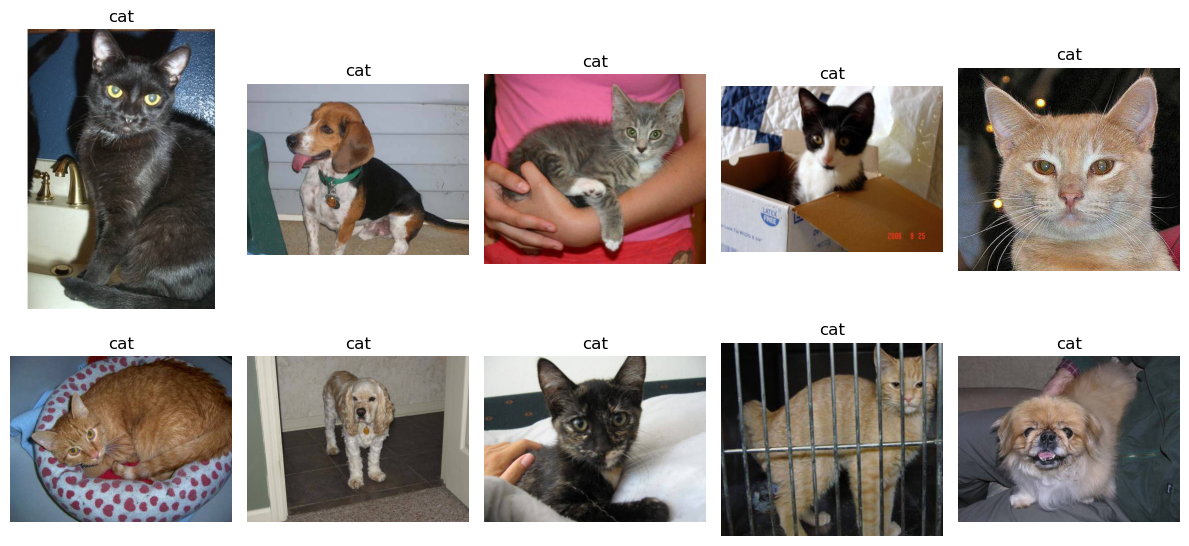

In [95]:
#예측 결과를 시각적으로 표현하기 위한 함수
class_=classes={0: 'cat', 1:'dog'}
def display_image_grid(images_filepaths, predicted_labels=(), cols=5):
    rows=len(images_filepaths)//cols
    figure, ax=plt.subplots(nrows=rows, ncols=cols, figsize=(12,6))
    for i, image_filepath in enumerate(images_filepaths):
        image=cv2.imread(image_filepath)
        image=cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        a=random.choice(res['id'].values)
        label=res.loc[res['id']==a, 'label'].values[0]
        if label>0.5:
            label=1
        else:
            label=0
        ax.ravel()[i].imshow(image)
        ax.ravel()[i].set_title(class_[label])
        ax.ravel()[i].set_axis_off()
    plt.tight_layout()
    plt.show()

#예측 결과에 대해 이미지와 함께 출력
display_image_grid(test_images_filepaths)

3. VGGNet

In [97]:
#필요한 라이브러리 호출
import copy #객체 복사를 위해 사용
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.utils.data as data
import torchvision
import torchvision.transforms as transforms
import torchvision.datasets as Datasets

device=torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [101]:
#VGG 모델 정의
class VGG(nn.Module):
    def __init__(self, features, output_dim):
        super().__init__()
        self.features=features #VGG 모델에 대한 매개변수에서 받아온 features 값을 self.features여기에 넣어줌
        self.avgpool=nn.AdaptiveAvgPool2d(7)
        self.classifier=nn.Sequential(
            nn.Linear(512*7*7, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(4096, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(4096, output_dim)
        ) # 완전 연결층과 출력층 정의

    def forward(self, x):
        x=self.features(x)
        x=self.avgpool(x)
        h=x.view(x.shape[0], -1)
        x=self.classifier(h)
        return x, h

In [105]:
# 모델 유형의 정의 >> VGG11, VGG13, VGG16, VGG19 
# 여기서 11,13,16,19는 전체 계층의 개수 / 이때 풀링층의 개수는 3,나머지 차가 합성곱층의 개수
# 숫자 : 출력 채널로 Conv2d로 수행하라는 의미이며, 다음 계층에서 입력 채널이 된다. 
# M : 최대풀링을 수행하라
vgg11_config=[64, 'M', 128, 'M', 256, 256, 'M', 512, 512, 'M', 512, 512, 'M']

vgg13_config=[64, 64, 'M', 128, 128, 'M', 256, 256, 'M', 512, 512, 'M', 512, 512, 'M']

vgg16_config=[64, 64, 'M', 128, 128, 'M', 256, 256, 256, 'M', 512, 512, 512, 'M',
              512, 512, 512, 'M']

vgg19_config=[64, 64, 'M', 128, 128, 'M', 256, 256, 256, 256, 'M', 512, 512, 512,
              512, 'M', 512, 512, 512, 512, 'M']

In [109]:
# VGG 계층 정의 >> vgg11_config 사용
def get_vgg_layers(config, batch_norm):
    layers=[]
    in_channels=3

    for c in config: #vgg11_config값들을 가져오기 >> 위에서 정의된 숫자와 문자의 값들이 실질적으로 기능으로 구현됨
        assert c=='M' or isinstance(c, int)
        if c=='M': # M이면 최대 풀링 적용
            layers+=[nn.MaxPool2d(kernel_size=2)]
        else: # 숫자이면 합성곱 Conv2d 적용
            conv2d=nn.Conv2d(in_channels, c, kernel_size=3, padding=1)
            if batch_norm: # 배치 정규화면 배치 정규화 + ReLu 적용
                layers+=[conv2d, nn.BatchNorm2d(c), nn.ReLU(inplace=True)]
            else: #아니면 렐루만
                layers+=[conv2d, nn.ReLU(inplace=True)]
            in_channels=c

    return nn.Sequential(*layers)

In [115]:
#모델 계층 생성 >> 배치 정규화에 대한 계층 추가
vgg11_layers=get_vgg_layers(vgg11_config, batch_norm=True)

#VGG11 계층 확인
print(vgg11_layers)

Sequential(
  (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (4): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (5): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (6): ReLU(inplace=True)
  (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (8): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (9): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (10): ReLU(inplace=True)
  (11): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (12): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (13): ReLU(inplace=True)
  (14): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, cei

In [117]:
# 모델에 대한 전체 네트워크 확인하기 >> vgg11_layers와 VGG()에서 정의한 완전 연결층과 출력층이 포함된 구성임
OUTPUT_DIM=2
model=VGG(vgg11_layers, OUTPUT_DIM)
print(model)

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (12): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (13): ReLU(inplace=True)
    (14): MaxPool2d(ke

In [119]:
# 사실 이미 훈련된 VGG11가 있어서 튜닝도 완료된 상태임 >> 바로 가져다쓰기
import torchvision.models as models
pretrained_model=models.vgg11_bn(pretrained=True) #vgg11_bn: VGG11 기본 모델에 배치 정규화가 적용된 모델 사용
print(pretrained_model)

/opt/anaconda3/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG11_BN_Weights.IMAGENET1K_V1`. You can also use `weights=VGG11_BN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/vgg11_bn-6002323d.pth" to /Users/bluecloud/.cache/torch/hub/checkpoints/vgg11_bn-6002323d.pth
100%|████████████████████████████████████████| 507M/507M [00:48<00:00, 11.0MB/s]


VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (12): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (13): ReLU(inplace=True)
    (14): MaxPool2d(ke

In [121]:
# 이미지에 대한 전처리 부분 정의
train_transforms=transforms.Compose([
    transforms.Resize((256,256)), 
    transforms.RandomRotation(5),   
    transforms.RandomHorizontalFlip(0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])])

test_transforms=transforms.Compose([
    transforms.Resize((256,256)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])])

In [123]:
#ImageFolder를 이용하여 데이터셋 불러오기
train_path='/Users/bluecloud/Documents/대학/유런/data/chap06/catanddog/train'
test_path='/Users/bluecloud/Documents/대학/유런/data/chap06/catanddog/test'

train_dataset=torchvision.datasets.ImageFolder(
    train_path,
    transform=train_transforms
)

test_dataset=torchvision.datasets.ImageFolder(
    test_path,
    transform=test_transforms
)

print(len(train_dataset)), print(len(test_dataset))

529
12


(None, None)

In [125]:
# 훈련 / 검증 데이터로 분할하기 >> 9:1
VALID_RATIO=0.9
n_train_examples=int(len(train_dataset)*VALID_RATIO)
n_valid_examples=len(train_dataset) - n_train_examples

train_data, valid_data=data.random_split(train_dataset,[n_train_examples, n_valid_examples])

In [127]:
#검증 데이터 전처리
valid_data=copy.deepcopy(valid_data)
valid_data.dataset.transform=test_transforms
#훈련, 검증, 테스트 데이터셋 수 확인 >> 이미지 데이터 수 확인
print(f'Number of training examples: {len(train_data)}')
print(f'Number of validation examples: {len(valid_data)}')
print(f'Number of testing examples: {len(test_dataset)}')

Number of training examples: 476
Number of validation examples: 53
Number of testing examples: 12


In [129]:
#메모리로 데이터 불러오기 with DataLoader & 한꺼번에 가져오는게 아니라 배치 사이즈만큼 나누어서 가져옴
BATCH_SIZE=128
train_iterator=data.DataLoader(train_data,shuffle=True,batch_size=BATCH_SIZE)

valid_iterator=data.DataLoader(valid_data,batch_size=BATCH_SIZE)

test_iterator=data.DataLoader(test_dataset,batch_size=BATCH_SIZE)

In [131]:
#옵티마이저와 손실 함수 정의
optimizer=optim.Adam(model.parameters(), lr=1e-7)
criterion=nn.CrossEntropyLoss()

model=model.to(device)
criterion=criterion.to(device)

In [133]:
#모델 정확도 측정 함수
def calculate_accuracy(y_pred, y):
    top_pred=y_pred.argmax(1, keepdim=True)
    correct=top_pred.eq(y.view_as(top_pred)).sum() 
    acc=correct.float()/y.shape[0]
    return acc

#모델 학습 함수 정의 >> 훈련 데이터셋을 이용
def train(model, iterator, optimizer, criterion, device):
    epoch_loss=0
    epoch_acc=0

    model.train()
    for (x,y) in iterator:
        x=x.to(device)
        y=y.to(device)

        optimizer.zero_grad()
        y_pred, _=model(x)
        loss=criterion(y_pred, y)
        acc=calculate_accuracy(y_pred, y)
        loss.backward()
        optimizer.step()

        epoch_loss+=loss.item()
        epoch_acc+=acc.item()
    return epoch_loss/len(iterator), epoch_acc/len(iterator)

#모델 성능 측정 함수 >> 검증 및 테스트 데이터셋을 이용
def evaluate(model, iterator, criterion, device):
    epoch_loss=0
    epoch_acc=0

    model.eval()
    with torch.no_grad():
        for(x,y) in iterator:
            x=x.to(device)
            y=y.to(device)
            y_pred, _=model(x)
            loss=criterion(y_pred, y)
            acc=calculate_accuracy(y_pred, y)
            epoch_loss+=loss.item()
            epoch_acc+=acc.item()
    return epoch_loss/len(iterator), epoch_acc/len(iterator)

#학습 시간 측정 함수 >> 모델의 학습 시간(시작, 종료)를 측정하기 위한 함수
def epoch_time(start_time, end_time):
    elapsed_time=end_time-start_time
    elapsed_mins=int(elapsed_time/60)
    elapsed_secs=int(elapsed_time-(elapsed_mins*60))
    return elapsed_mins, elapsed_secs

In [139]:
EPOCHS = 5
best_valid_loss = float('inf')
for epoch in range(EPOCHS) : 
    start_time = time.monotonic() 
    train_loss, train_acc = train(model, train_iterator, optimizer, criterion, device)
    valid_loss, valid_acc = evaluate(model,valid_iterator, criterion, device)

    if valid_loss < best_valid_loss: #valid_loss가 가장 작은 값을 구해 그 상태의 모델을 VGG-model.pt여기에 저장 
        best_valid_loss = valid_loss 
        torch.save(model.state_dict(),'/Users/bluecloud/Documents/대학/유런/data/chap06/VGG-model.pt')
    end_time = time. monotonic()
    epoch_mins, epoch_secs = epoch_time(start_time, end_time) # 모델 훈련에 대한 시작과 종료 시간을 저장
    
    print(f'Epoch: {epoch+1:02} | Epoch Time: {epoch_mins}m {epoch_secs}s')
    print(f'\tTrain Loss: {train_loss:.3f} | Train Acc: {train_acc*100: .2f}%')
    print(f'\t Valid. Loss: {valid_loss:.3f}|Valid. Acc: {valid_acc*100:.2f}%')

Epoch: 01 | Epoch Time: 5m 18s
	Train Loss: 0.700 | Train Acc:  50.70%
	 Valid. Loss: 0.693|Valid. Acc: 43.40%
Epoch: 02 | Epoch Time: 5m 38s
	Train Loss: 0.700 | Train Acc:  48.10%
	 Valid. Loss: 0.693|Valid. Acc: 43.40%
Epoch: 03 | Epoch Time: 6m 35s
	Train Loss: 0.707 | Train Acc:  48.52%
	 Valid. Loss: 0.693|Valid. Acc: 43.40%
Epoch: 04 | Epoch Time: 5m 49s
	Train Loss: 0.699 | Train Acc:  48.79%
	 Valid. Loss: 0.693|Valid. Acc: 41.51%
Epoch: 05 | Epoch Time: 6m 8s
	Train Loss: 0.696 | Train Acc:  53.17%
	 Valid. Loss: 0.693|Valid. Acc: 58.49%


In [143]:
#VGG-model.pt을 불려와 테스트 데이터셋에 대한 성능 측정
model.load_state_dict(torch.load('/Users/bluecloud/Documents/대학/유런/data/chap06/VGG-model.pt'))
test_lost, test_acc=evaluate(model, test_iterator, criterion, device)
print(f'Test Loss: {test_lost:.3f} | Test Acc: {test_acc*100:.2f}%')

Test Loss: 0.692 | Test Acc: 58.33%


In [145]:
#테스트 데이터셋을 이용한 모델의 예측 확인 함수
def get_predictions(model, iterator):
    model.eval()
    images=[]
    labels=[]
    probs=[]

    with torch.no_grad():
        for (x,y) in iterator:
            x=x.to(device)
            y_pred, _=model(x)
            y_prob=F.softmax(y_pred, dim=-1)
            top_pred=y_prob.argmax(1, keepdim=True) #argmax: 배열에서 가장 큰 값의 인덱스를 찾을 때 사용
            images.append(x.cpu())
            labels.append(y.cpu())
            probs.append(y_prob.cpu())

    images=torch.cat(images, dim=0)
    labels=torch.cat(labels, dim=0)
    probs=torch.cat(probs, dim=0)
    return images, labels, probs

In [147]:
# get_predictions()의 반환값으로 모델의 가장 정확한 예측값을 추출
images, labels, probs=get_predictions(model, test_iterator)
pred_labels=torch.argmax(probs,1)
corrects=torch.eq(labels, pred_labels)
correct_examples=[]

for image, label, prob, correct in zip(images, labels, probs, corrects):    
    if correct:
        correct_examples.append((image, label, prob))

correct_examples.sort(reverse=True, key=lambda x: torch.max(x[2], dim=0).values)

In [149]:
# 이미지 출력을 위한 전처리
def normalize_image(image):
    image_min=image.min()
    image_max=image.max()
    image.clamp_(min=image_min, max=image_max)
    image.add_(-image_min).div_(image_max-image_min+1e-5)   
    return image

In [151]:
#모델이 정확하게 예측한 이미지 출력 함수
import matplotlib.pyplot as plt

def plot_most_correct(correct, classes, n_images, normalize=True):
    rows=int(np.sqrt(n_images))
    cols=int(np.sqrt(n_images))
    fig=plt.figure(figsize=(25,20))
    for i in range(rows*cols):
        ax=fig.add_subplot(rows, cols, i+1)
        image, true_label, probs=correct[i]
        image=image.permute(1,2,0)  #축 변경
        true_prob=probs[true_label]
        correct_prob, correct_label=torch.max(probs, dim=0)
        true_class=classes[true_label]
        correct_class=classes[correct_label]

        if normalize:
            image=normalize_image(image)

        ax.imshow(image.cpu().numpy())
        ax.set_title(f'true label: {true_class} ({true_prob:.3f})\n'\
                     f'pred label: {correct_class} ({correct_prob:.3f})')
        ax.axis('off')
    fig.subplots_adjust(hspace=0.4)
     

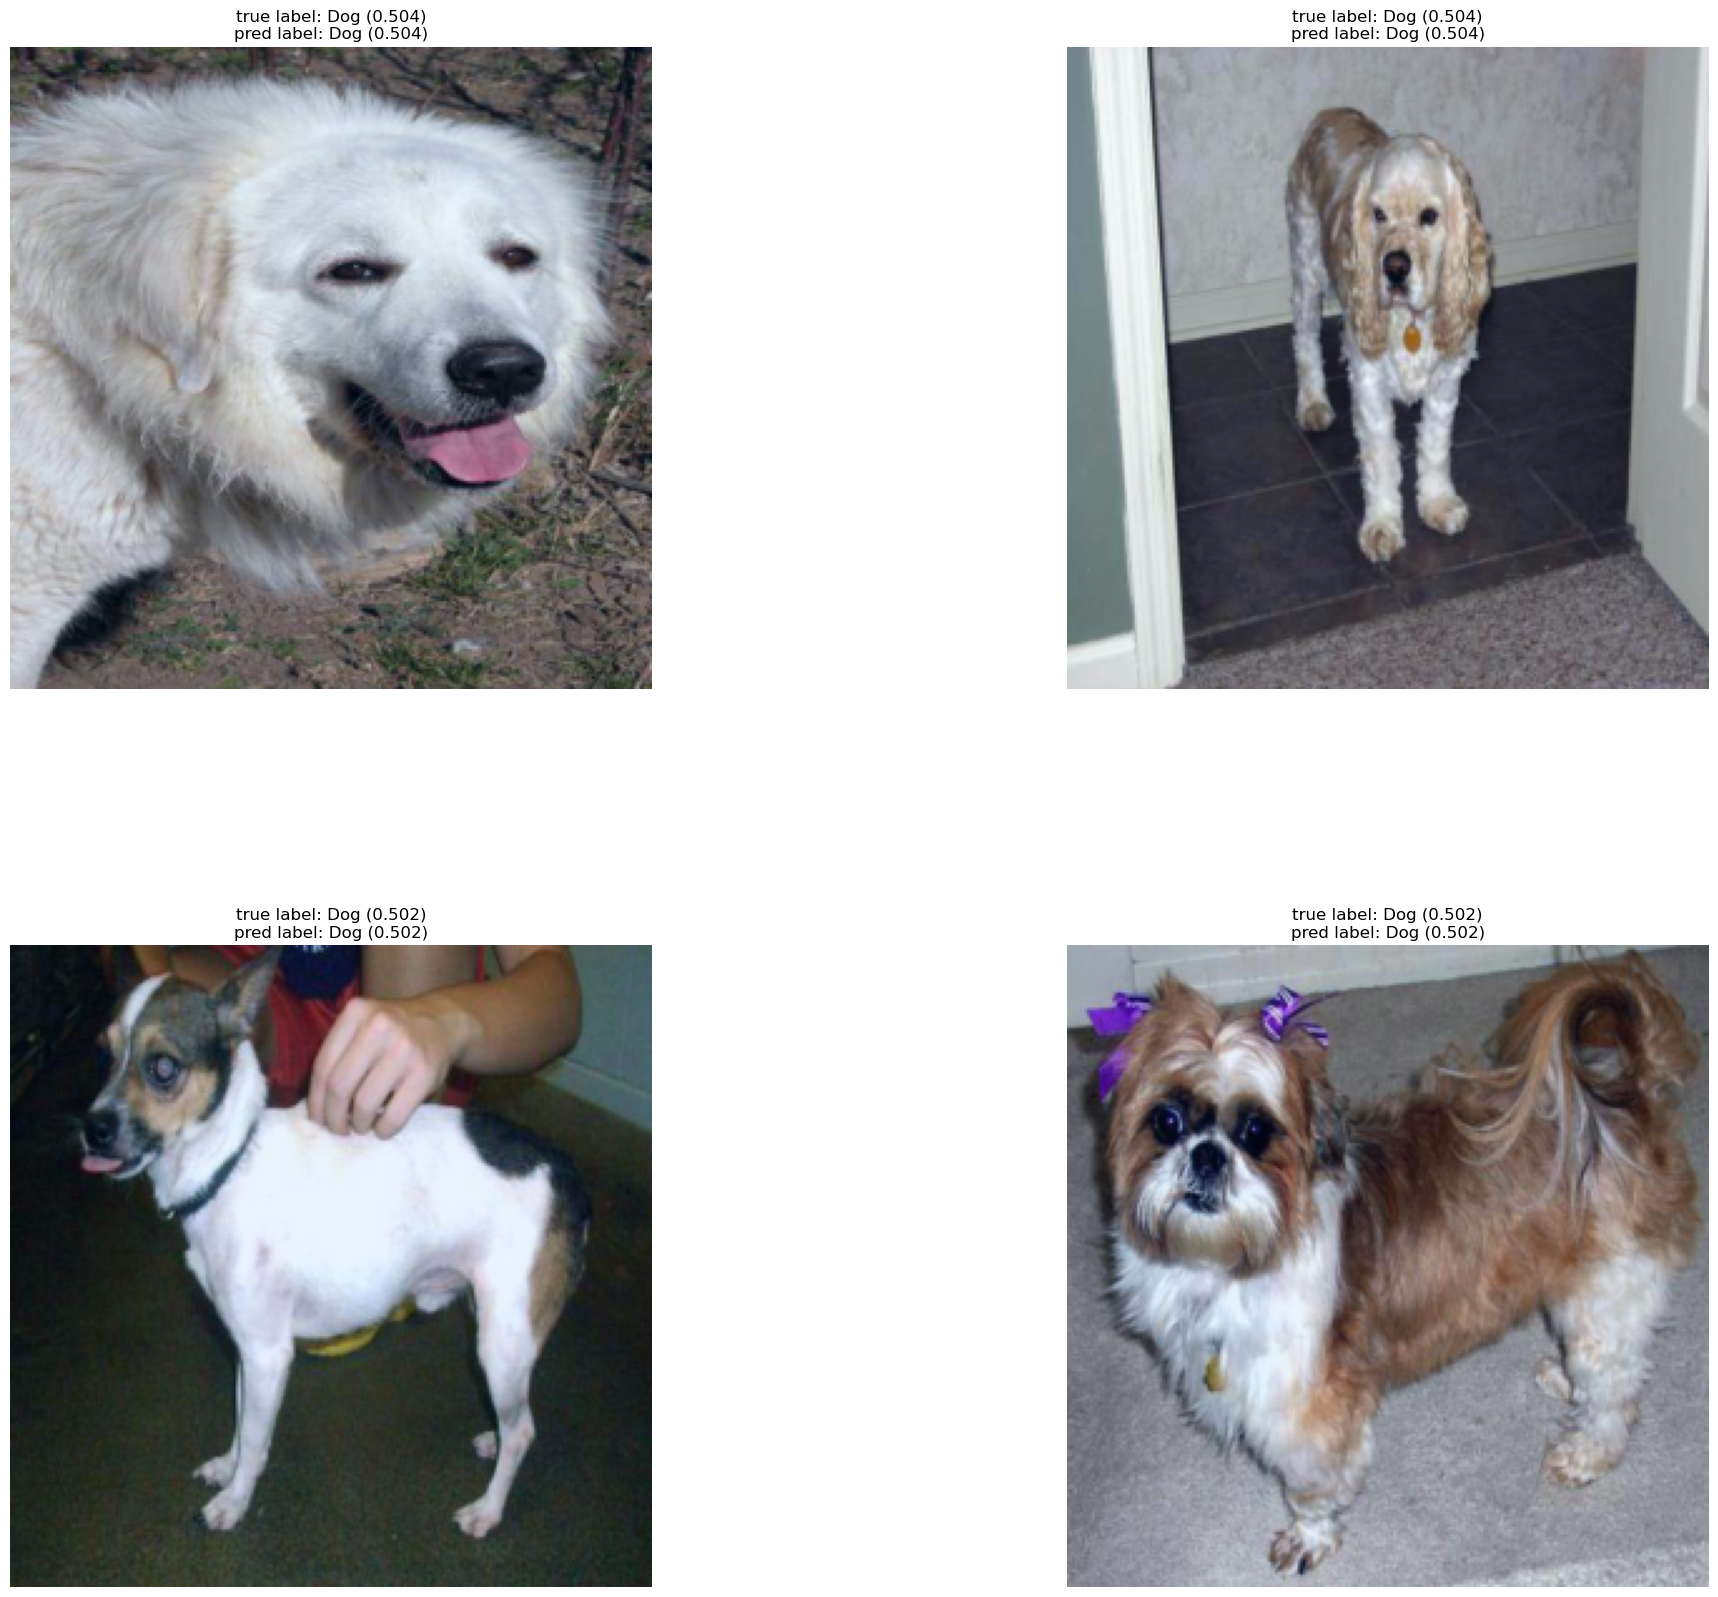

In [153]:
# 예측 결과 이미지 출력
classes=test_dataset.classes
N_IMAGES=5
plot_most_correct(correct_examples, classes, N_IMAGES)